## Tarea 4 - Modelo Logístico y Enfoque bayesiano

**Universidad Nacional Abierta y a Distancia — UNAD**  
**Curso:** Métodos Estadísticos en la Ciencia de Datos y Analítica

### **Paso 1: Descargue la base de datos “dynamic_pricing.csv” desde el siguiente enlace:**
https://www.kaggle.com/datasets/arashnic/dynamic-pricing-dataset 

### Dataset: Dynamic Pricing (Empresa de Viajes Compartidos)

**Variables utilizadas:**
- `Number_of_Riders` → Número de pasajeros por viaje  
- `Expected_Ride_Duration` → Duración esperada del viaje (equivalente a Trip_Distance)  
- `Customer_Loyalty_Status` → Nivel de fidelidad del cliente (Regular / Silver / Gold), codificado como ordinal  
- `Average_Ratings` → Calificación del viaje → **variable respuesta**, binarizada como:
  - `0` = servicio regular (calificación < 4)
  - `1` = servicio excelente (calificación ≥ 4)

### Librerías y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)

# ✅ Optimización para Windows sin g++ ────────────────────────────────────────
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="          # desactiva compilación C++
os.environ["OMP_NUM_THREADS"] = "1"            # evita conflictos de hilos
os.environ["MKL_NUM_THREADS"] = "1"            # estabiliza operaciones numéricas
# ─────────────────────────────────────────────────────────────────────────────

import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings("ignore")

SEED = 2026
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("Entorno listo.")
print(f"PyMC {pm.__version__} | ArviZ {az.__version__}")

Entorno listo.
PyMC 5.28.5 | ArviZ 0.23.4


### Cargar y exploración del conjunto de datos

Se carga el archivo dynamic_pricing.csv y se realiza una exploración inicial para entender la estructura de los datos, identificar posibles problemas y preparar las variables para el modelo.

In [2]:
# ── Carga del dataset ────────────────────────────────────────────────────────
df = pd.read_csv("Anexo 1 - Base de Datos dynamic_pricing.csv")

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\n📋 Primeras filas:')
df.head()

Dataset cargado: 1000 filas × 10 columnas

📋 Primeras filas:


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [36]:
# ── Calidad de los datos ─────────────────────────────────────────────────────
print(' Tipos de datos y valores nulos:')
print(pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Únicos': df.nunique()
}).to_string())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print('\n El dataset no presenta valores nulos ni duplicados. No requiere limpieza.')

 Tipos de datos y valores nulos:
                            Tipo  Nulos  Únicos
Number_of_Riders           int64      0      81
Number_of_Drivers          int64      0      79
Location_Category         object      0       3
Customer_Loyalty_Status   object      0       3
Number_of_Past_Rides       int64      0     101
Average_Ratings          float64      0     151
Time_of_Booking           object      0       4
Vehicle_Type              object      0       2
Expected_Ride_Duration     int64      0     171
Historical_Cost_of_Ride  float64      0    1000
Trip_Rating_bin            int64      0       2
Customer_Loyalty           int64      0       3

Filas duplicadas: 0

 El dataset no presenta valores nulos ni duplicados. No requiere limpieza.


### **Paso 2: Transformación de la variable y ajuste del modelo logístico:**

#### **2.0.	 Recodifique la variable `Average_Ratings` como binaria:**

 - 0 → servicio regular (calificación < 4)  
 - 1 → servicio excelente (calificación ≥ 4) 

Defina las variables predictoras: `Expected_Ride_Duration`, `Number_of_Riders`, `Customer_Loyalty_Status`.  
Ajuste un modelo de regresión logística binaria e incluya:  

 - Ecuación del modelo  
 - Coeficientes estimados  
 - Significancia estadística (p-valores)

Distribución de la variable respuesta binarizada:
Trip_Rating_bin
Excelente (≥ 4)    686
Regular (< 4)      314
Name: count, dtype: int64

Tasa de servicio excelente: 68.60%


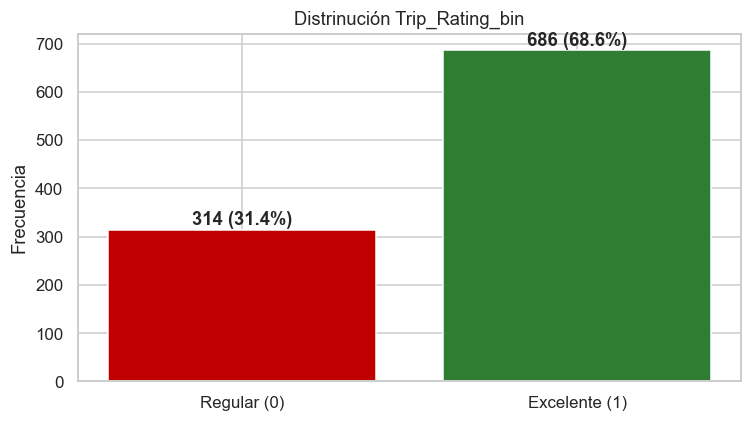


Codificación de Customer_Loyalty_Status:
Customer_Loyalty_Status  Customer_Loyalty
Gold                     2                   313
Regular                  0                   320
Silver                   1                   367
Name: count, dtype: int64


In [37]:
# ── Binarización de la variable respuesta ─────────────────────────────────
df["Trip_Rating_bin"] = (df["Average_Ratings"] >= 4).astype(int)
print("Distribución de la variable respuesta binarizada:")
print(df["Trip_Rating_bin"].value_counts().rename({0: "Regular (< 4)", 1: "Excelente (≥ 4)"}))
print(f"\nTasa de servicio excelente: {df['Trip_Rating_bin'].mean():.2%}")

fig, ax = plt.subplots(figsize=(7, 4))
counts = df["Trip_Rating_bin"].value_counts().sort_index()
ax.bar(["Regular (0)", "Excelente (1)"], counts.values,
       color=["#C00000", "#2E7D32"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f"{v} ({v/len(df)*100:.1f}%)",
            ha="center", fontweight="bold")
ax.set_title("Distrinución Trip_Rating_bin")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("Trip_Rating_bin.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Codificación ordinal de Customer_Loyalty_Status ───────────────────────
loyalty_map = {"Regular": 0, "Silver": 1, "Gold": 2}
df["Customer_Loyalty"] = df["Customer_Loyalty_Status"].map(loyalty_map)
print("\nCodificación de Customer_Loyalty_Status:")
print(df[["Customer_Loyalty_Status", "Customer_Loyalty"]].value_counts().sort_index())

In [38]:
# ── Definición de variables y división train/test ────────────────────────────
# Variables predictoras: Number_of_Riders, Expected_Ride_Duration, Customer_Loyalty
PREDICTORAS = ["Number_of_Riders", "Expected_Ride_Duration", "Customer_Loyalty"]
TARGET = "Trip_Rating_bin"

X = df[PREDICTORAS].astype(float)
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

# Reset de índices para evitar desalineación en statsmodels
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tasa excelente en train: {y_train.mean():.2%}  |  en test: {y_test.mean():.2%}")

# ── Ajuste del modelo logístico completo (statsmodels) ───────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

modelo_completo = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=200)
print("\n" + "="*60)
print("RESUMEN DEL MODELO LOGÍSTICO COMPLETO")
print("="*60)
print(modelo_completo.summary())

Train: (700, 3)  |  Test: (300, 3)
Tasa excelente en train: 68.57%  |  en test: 68.67%

RESUMEN DEL MODELO LOGÍSTICO COMPLETO
                           Logit Regression Results                           
Dep. Variable:        Trip_Rating_bin   No. Observations:                  700
Model:                          Logit   Df Residuals:                      696
Method:                           MLE   Df Model:                            3
Date:                Mon, 11 May 2026   Pseudo R-squ.:                0.005038
Time:                        01:39:47   Log-Likelihood:                -433.55
converged:                       True   LL-Null:                       -435.74
Covariance Type:            nonrobust   LLR p-value:                    0.2222
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1.0062      0.309      3.261     

In [39]:
# ── Ecuación del modelo estimado ─────────────────────────────────────────────
params = modelo_completo.params
print("\n ECUACIÓN DEL MODELO LOGÍSTICO:")
print("="*90)
print(f"  logit(P) = ln[P/(1-P)]")
print(f"  logit(P) = {params['const']:.4f}")
for var in PREDICTORAS:
    signo = "+" if params[var] >= 0 else ""
    print(f"             {signo}{params[var]:.4f} × {var}")
print()
print("  P(excelente) = 1 / (1 + e^(-logit(P)))")

# Tabla completa de coeficientes y p-valores
tabla_coefs = pd.DataFrame({
    "Variable":     modelo_completo.params.index,
    "Coeficiente":  np.round(modelo_completo.params.values, 4),
    "Error Estándar": np.round(modelo_completo.bse.values, 4),
    "Estadístico z": np.round(modelo_completo.tvalues.values, 4),
    "p-valor":       np.round(modelo_completo.pvalues.values, 4),
    "Significativo": np.where(modelo_completo.pvalues.values < 0.05, "SÍ ✓", "no")
})
print("\n TABLA DE COEFICIENTES:")
print(tabla_coefs.to_string(index=False))


 ECUACIÓN DEL MODELO LOGÍSTICO:
  logit(P) = ln[P/(1-P)]
  logit(P) = 1.0062
             +0.0026 × Number_of_Riders
             -0.0028 × Expected_Ride_Duration
             -0.0943 × Customer_Loyalty

  P(excelente) = 1 / (1 + e^(-logit(P)))

 TABLA DE COEFICIENTES:
              Variable  Coeficiente  Error Estándar  Estadístico z  p-valor Significativo
                 const       1.0062          0.3086         3.2610   0.0011          SÍ ✓
      Number_of_Riders       0.0026          0.0034         0.7671   0.4430            no
Expected_Ride_Duration      -0.0028          0.0017        -1.6732   0.0943            no
      Customer_Loyalty      -0.0943          0.1032        -0.9144   0.3605            no


#### **2.1.	 Interpretación de Odds Ratios y matriz de desempeño**

Calcule e interprete los Odds Ratios (OR) para cada variable:  
¿Cómo influye cada predictor en la probabilidad de recibir una calificación excelente?  
Construya la matriz de confusión (con 30% de datos de prueba).  

Calcule los indicadores de desempeño:  
 - Precisión (Accuracy)  
 - Sensibilidad (Recall)  
 - Especificidad   

Analice la calidad del modelo como clasificador binario.

TABLA DE ODDS RATIOS (OR):
              Variable  Coeficiente  p-valor  Odds Ratio  OR IC 95% inf  OR IC 95% sup Significativo
                 const       1.0062   0.0011      2.7353         1.4940         5.0080          SÍ ✓
      Number_of_Riders       0.0026   0.4430      1.0026         0.9959         1.0094            no
Expected_Ride_Duration      -0.0028   0.0943      0.9972         0.9939         1.0005            no
      Customer_Loyalty      -0.0943   0.3605      0.9100         0.7434         1.1139            no


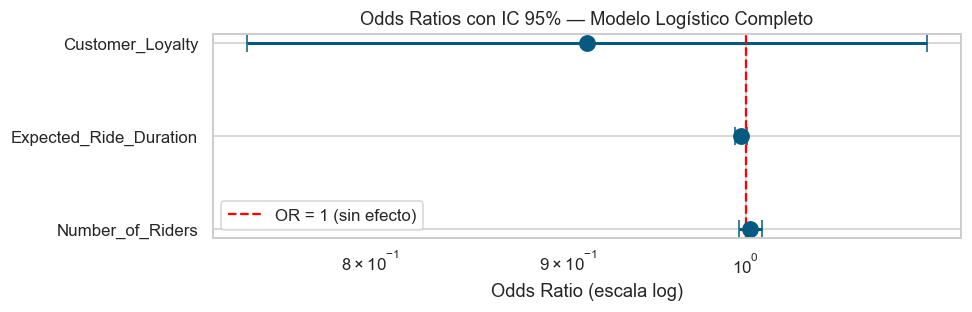

In [40]:
# ── Odds Ratios con intervalos de confianza al 95% ──────────────────────────
ci = modelo_completo.conf_int()
tabla_or = pd.DataFrame({
    "Variable":      modelo_completo.params.index,
    "Coeficiente":   np.round(modelo_completo.params.values, 4),
    "p-valor":       np.round(modelo_completo.pvalues.values, 4),
    "Odds Ratio":    np.round(np.exp(modelo_completo.params.values), 4),
    "OR IC 95% inf": np.round(np.exp(ci.iloc[:, 0].values), 4),
    "OR IC 95% sup": np.round(np.exp(ci.iloc[:, 1].values), 4),
    "Significativo": np.where(modelo_completo.pvalues.values < 0.05, "SÍ ✓", "no")
})
print("TABLA DE ODDS RATIOS (OR):")
print(tabla_or.to_string(index=False))

# Visualización de Odds Ratios
fig, ax = plt.subplots(figsize=(9, 3))
vars_plot = PREDICTORAS
or_vals  = np.exp(modelo_completo.params[vars_plot].values)
or_inf   = np.exp(ci.loc[vars_plot, 0].values)
or_sup   = np.exp(ci.loc[vars_plot, 1].values)
pos = np.arange(len(vars_plot))

ax.errorbar(or_vals, pos,
            xerr=[or_vals - or_inf, or_sup - or_vals],
            fmt="o", color="#065A82", markersize=10, capsize=6, lw=2)
ax.axvline(1, color="red", linestyle="--", lw=1.5, label="OR = 1 (sin efecto)")
ax.set_yticks(pos)
ax.set_yticklabels(vars_plot, fontsize=11)
ax.set_xlabel("Odds Ratio (escala log)")
ax.set_xscale("log")
ax.set_title("Odds Ratios con IC 95% — Modelo Logístico Completo")
ax.legend()
plt.tight_layout()
plt.savefig("OddsRatiosCon_IC.png", dpi=130, bbox_inches="tight")
plt.show()

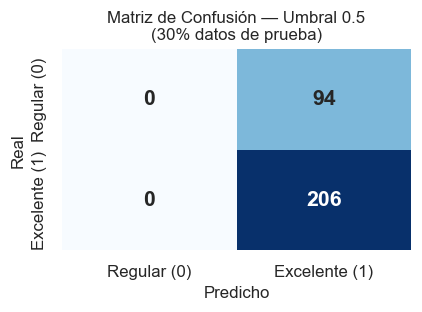


INDICADORES DE DESEMPEÑO:
─────────────────────────────────────────────
  Verdaderos Positivos (TP):  206
  Falsos Positivos (FP):      94
  Verdaderos Negativos (TN):  0
  Falsos Negativos (FN):      0
─────────────────────────────────────────────
  Precisión (Accuracy):       0.6867  (68.67%)
  Sensibilidad (Recall):      1.0000  (100.00%)
  Especificidad:              0.0000  (0.00%)
  Precisión (Precision):      0.6867  (68.67%)
  F1-Score:                   0.8142
  AUC-ROC:                    0.5072


In [41]:
# ── Matriz de confusión y métricas de desempeño (umbral 0.5) ─────────────────
y_prob_test = modelo_completo.predict(X_test_sm)
y_pred_05   = (y_prob_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm.ravel()

accuracy      = (tp + tn) / len(y_test)
sensibilidad  = tp / (tp + fn) if (tp + fn) > 0 else 0   # Recall
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
f1            = 2 * tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
auc_roc       = auc(*roc_curve(y_test, y_prob_test)[:2])

# Visualización de la matriz de confusión
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Regular (0)", "Excelente (1)"],
            yticklabels=["Regular (0)", "Excelente (1)"],
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_xlabel("Predicho", fontsize=11)
ax.set_ylabel("Real", fontsize=11)
ax.set_title("Matriz de Confusión — Umbral 0.5\n(30% datos de prueba)", fontsize=11)
plt.tight_layout()
plt.savefig("Matriz_de_Confusion.png", dpi=130, bbox_inches="tight")
plt.show()

# Tabla de indicadores
print("\nINDICADORES DE DESEMPEÑO:")
print("─"*45)
print(f"  Verdaderos Positivos (TP):  {tp}")
print(f"  Falsos Positivos (FP):      {fp}")
print(f"  Verdaderos Negativos (TN):  {tn}")
print(f"  Falsos Negativos (FN):      {fn}")
print("─"*45)
print(f"  Precisión (Accuracy):       {accuracy:.4f}  ({accuracy:.2%})")
print(f"  Sensibilidad (Recall):      {sensibilidad:.4f}  ({sensibilidad:.2%})")
print(f"  Especificidad:              {especificidad:.4f}  ({especificidad:.2%})")
print(f"  Precisión (Precision):      {precision_val:.4f}  ({precision_val:.2%})")
print(f"  F1-Score:                   {f1:.4f}")
print(f"  AUC-ROC:                    {auc_roc:.4f}")

#### **2.2.	 Comparación de desempeño de modelos**

Compare al menos dos modelos logísticos:
 - Modelo completo (todas las variables)   
 - Modelo reducido (sin una o más variables predictoras)

Reporte y compare las siguientes métricas:
 - Pseudo-R² (McFadden o Nagelkerke)  
 - AIC  
 - Curva ROC y AUC (opcional)  

Concluya cuál modelo tiene mejor desempeño y justifique la elección.


In [42]:
# ── Modelo reducido: sin Customer_Loyalty ───────────────────────────────────

# FIX: reset_index en train/test para alinear índices con statsmodels
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Reconstruir las matrices con constante usando los índices ya limpios
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
# (re-ajustar modelo_completo si fue ajustado antes del reset)
modelo_completo = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=200)

X_train_red = sm.add_constant(X_train[["Number_of_Riders", "Expected_Ride_Duration"]]) #
X_test_red  = sm.add_constant(X_test[["Number_of_Riders",  "Expected_Ride_Duration"]]) #
modelo_reducido = sm.Logit(y_train, X_train_red).fit(disp=False, maxiter=200)

# ── Modelo nulo (solo intercepto) para Pseudo-R² ────────────────────────────
# ✅ FIX: usar directamente np.ones como Serie con índice limpio,
#         no pd.DataFrame con columna "const" (statsmodels ya agrega la constante)
X_null = pd.DataFrame({"const": np.ones(len(y_train))})
modelo_nulo = sm.Logit(y_train, X_null).fit(disp=False)

# ── Función para calcular métricas resumidas (sin cambios) ──────────────────
def metricas_modelo(modelo, X_test_sm_m, nombre):
    y_prob = modelo.predict(X_test_sm_m)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc   = (tp + tn) / len(y_test)
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_v  = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    auc_v = auc(*roc_curve(y_test, y_prob)[:2])
    pseudo_r2 = 1 - (modelo.llf / modelo_nulo.llf)
    return {
        "Modelo": nombre,
        "Variables": str(list(modelo.params.index[1:])),
        "Log-Lik": round(modelo.llf, 2),
        "AIC": round(modelo.aic, 2),
        "BIC": round(modelo.bic, 2),
        "Pseudo-R² McFadden": round(pseudo_r2, 4),
        "Accuracy (test)": round(acc, 4),
        "Recall (test)": round(rec, 4),
        "F1 (test)": round(f1_v, 4),
        "AUC-ROC (test)": round(auc_v, 4)
    }

m1 = metricas_modelo(modelo_completo, X_test_sm,  "Completo (3 vars)")
m2 = metricas_modelo(modelo_reducido, X_test_red, "Reducido (sin Loyalty)")

tabla_comp = pd.DataFrame([m1, m2])
print(" COMPARACIÓN DE MODELOS:")
print(tabla_comp[["Modelo", "AIC", "BIC", "Pseudo-R² McFadden",
                   "Accuracy (test)", "Recall (test)", "AUC-ROC (test)"]].to_string(index=False))

 COMPARACIÓN DE MODELOS:
                Modelo    AIC    BIC  Pseudo-R² McFadden  Accuracy (test)  Recall (test)  AUC-ROC (test)
     Completo (3 vars) 875.09 893.30              0.0050           0.6867            1.0          0.5072
Reducido (sin Loyalty) 873.93 887.58              0.0041           0.6867            1.0          0.5107


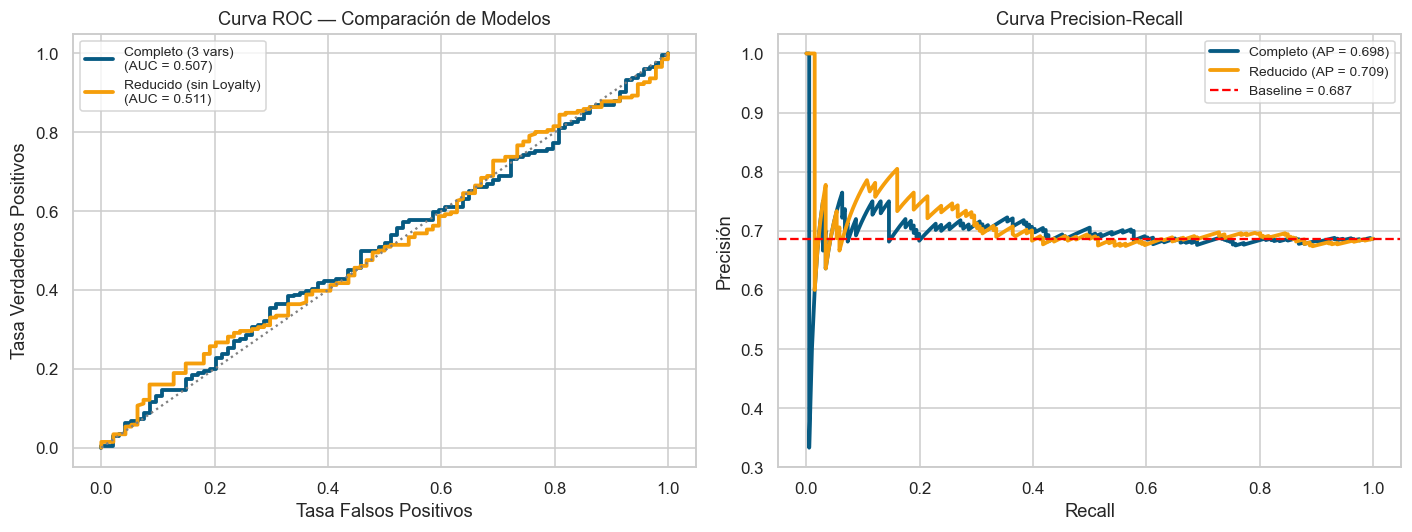


 CONCLUSIÓN DE LA COMPARACIÓN:
────────────────────────────────────────────────────────────
  Los modelos son comparables (ΔAIC = 1.2).
  Principio de parsimonia → preferir el modelo REDUCIDO.


In [43]:
# ── Curvas ROC: modelo completo vs reducido ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for modelo, X_sm, label, color in [
    (modelo_completo, X_test_sm,  "Completo (3 vars)", "#065A82"),
    (modelo_reducido, X_test_red, "Reducido (sin Loyalty)", "#F59E0B")
]:
    y_p = modelo.predict(X_sm)
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2.5, color=color, label=f"{label}\n(AUC = {auc_val:.3f})")

axes[0].plot([0,1],[0,1], ":", color="gray", lw=1.5)
axes[0].set_xlabel("Tasa Falsos Positivos")
axes[0].set_ylabel("Tasa Verdaderos Positivos")
axes[0].set_title("Curva ROC — Comparación de Modelos")
axes[0].legend(fontsize=9)

# Precision-Recall
for modelo, X_sm, label, color in [
    (modelo_completo, X_test_sm,  "Completo", "#065A82"),
    (modelo_reducido, X_test_red, "Reducido", "#F59E0B")
]:
    y_p = modelo.predict(X_sm)
    prec, rec, _ = precision_recall_curve(y_test, y_p)
    ap = average_precision_score(y_test, y_p)
    axes[1].plot(rec, prec, lw=2.5, color=color, label=f"{label} (AP = {ap:.3f})")

baseline = y_test.mean()
axes[1].axhline(baseline, color="red", ls="--", lw=1.5,
                label=f"Baseline = {baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=130, bbox_inches="tight")
plt.show()

# Conclusión de la comparación
print("\n CONCLUSIÓN DE LA COMPARACIÓN:")
print("─"*60)
delta_aic = m1['AIC'] - m2['AIC']
if delta_aic < -2:
    print(f"  El modelo COMPLETO es preferible: AIC {m1['AIC']:.1f} vs {m2['AIC']:.1f}")
    print(f"  (ΔAIC = {delta_aic:.1f}). La variable Customer_Loyalty agrega información.")
elif delta_aic > 2:
    print(f"  El modelo REDUCIDO es preferible: AIC {m2['AIC']:.1f} vs {m1['AIC']:.1f}")
    print(f"  Customer_Loyalty no mejora el ajuste en términos de AIC.")
else:
    print(f"  Los modelos son comparables (ΔAIC = {delta_aic:.1f}).")
    print(f"  Principio de parsimonia → preferir el modelo REDUCIDO.")

#### **2.3.	 Introducción a la inferencia bayesiana**

Explique los elementos del enfoque bayesiano:  
 - Prior: conocimiento previo o creencia inicial (por ejemplo, sobre Customer_Loyalty).  
 - Verosimilitud: información derivada de los datos observados.  
 - Posterior: distribución actualizada después de observar los datos.  
 - Incluya un ejemplo ilustrativo (por ejemplo, estimar la fidelidad promedio del cliente). 

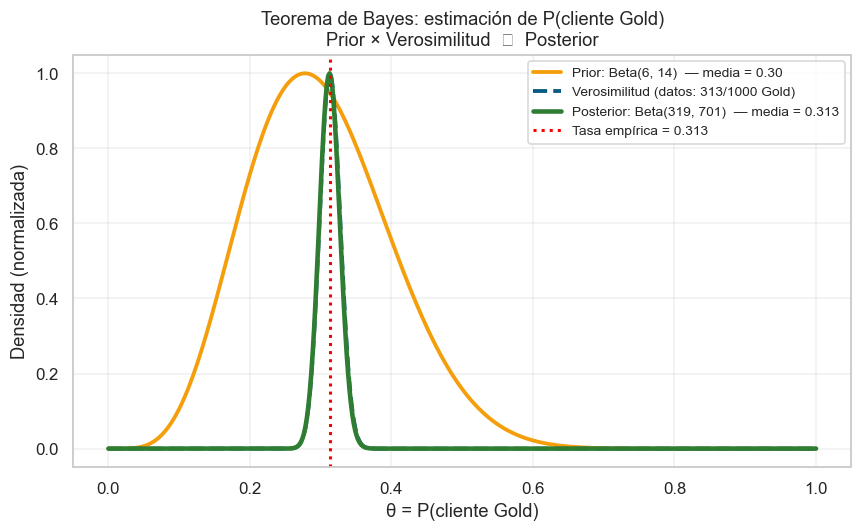


 RESULTADO BAYESIANO:
  Prior media:        0.300
  Tasa empírica Gold: 0.313
  Posterior media:    0.313
  HDI 95%:            [0.285, 0.342]


In [23]:
# ── Ilustración del teorema de Bayes para Customer_Loyalty ───────────────────
# Estimamos la proporción de clientes Gold en la población
# usando una distribución Beta conjugada con la Binomial

# Observaciones: n clientes con nivel Gold
n_total = len(df)
n_gold  = (df["Customer_Loyalty_Status"] == "Gold").sum()
n_no_gold = n_total - n_gold
p_gold_empirica = n_gold / n_total

theta = np.linspace(0, 1, 500)

# Prior: conocimiento previo sobre la proporción de clientes Gold
# Prior informativa: creemos que ~30% son Gold (Beta(6, 14) ≈ media 0.30)
prior_a, prior_b = 6, 14
prior = stats.beta.pdf(theta, prior_a, prior_b)

# Verosimilitud: datos observados (Binomial → posterior Beta conjugada)
# Posterior: Beta(alpha + n_gold, beta + n_no_gold)
post_a = prior_a + n_gold
post_b = prior_b + n_no_gold
posterior = stats.beta.pdf(theta, post_a, post_b)

# Likelihood (proporcional a la Binomial)
likelihood = stats.beta.pdf(theta, n_gold + 1, n_no_gold + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta, prior / prior.max(), lw=2.5, color="#F59E0B",
        label=f"Prior: Beta({prior_a}, {prior_b})  — media = {prior_a/(prior_a+prior_b):.2f}")
ax.plot(theta, likelihood / likelihood.max(), lw=2.5, color="#065A82", linestyle="--",
        label=f"Verosimilitud (datos: {n_gold}/{n_total} Gold)")
ax.plot(theta, posterior / posterior.max(), lw=3, color="#2E7D32",
        label=f"Posterior: Beta({post_a}, {post_b})  — media = {post_a/(post_a+post_b):.3f}")
ax.axvline(p_gold_empirica, color="red", ls=":", lw=2,
           label=f"Tasa empírica = {p_gold_empirica:.3f}")

ax.set_xlabel("θ = P(cliente Gold)", fontsize=12)
ax.set_ylabel("Densidad (normalizada)")
ax.set_title("Teorema de Bayes: estimación de P(cliente Gold)\n"
             "Prior × Verosimilitud  ∝  Posterior")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Teorema_de_Bayes.png", dpi=130, bbox_inches="tight")
plt.show()

# HDI 95% del posterior
hdi_inf = stats.beta.ppf(0.025, post_a, post_b)
hdi_sup = stats.beta.ppf(0.975, post_a, post_b)
print(f"\n RESULTADO BAYESIANO:")
print(f"  Prior media:        {prior_a/(prior_a+prior_b):.3f}")
print(f"  Tasa empírica Gold: {p_gold_empirica:.3f}")
print(f"  Posterior media:    {post_a/(post_a+post_b):.3f}")
print(f"  HDI 95%:            [{hdi_inf:.3f}, {hdi_sup:.3f}]")

#### **2.4.	 Simulación de estimación bayesiana**

Simule la estimación bayesiana de una media poblacional (por ejemplo, Trip_Distance).

Defina:  
 - Una prior informativa (media = 7, desviación estándar = 2).  
 - Una prior no informativa (distribución plana).  

Utilice métodos de simulación como Monte Carlo, o software como PyMC, Stan, JAGS o bayesplot (R).

Expected_Ride_Duration — media empírica: 99.59 | desv. estándar: 49.14
 Estimación bayesiana completada.


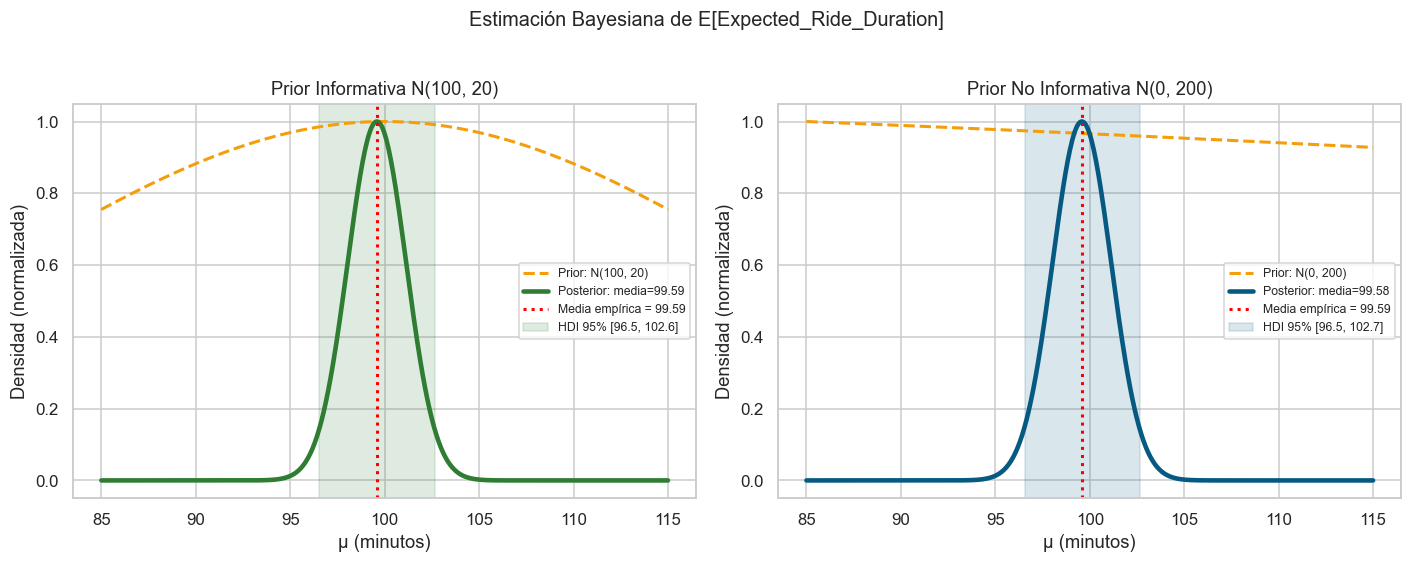


 RESUMEN DE ESTIMACIONES:
  Media empírica:                  99.59 min
  Posterior (prior informativa):   99.59 min  HDI95% [96.55, 102.64]
  Posterior (prior no informativa):99.58 min  HDI95% [96.55, 102.66]

  ▶ Con 1000 observaciones ambas priors convergen al mismo posterior.
    La prior informativa produce un HDI ligeramente más estrecho.


In [26]:
# ── Estimación bayesiana de la media de Expected_Ride_Duration ───────────────
# Método Monte Carlo 
data_dist = df["Expected_Ride_Duration"].values.astype(float)
n = len(data_dist)
media_emp = data_dist.mean()
std_emp   = data_dist.std()

print(f"Expected_Ride_Duration — media empírica: {media_emp:.2f} | desv. estándar: {std_emp:.2f}")

# ── Modelo conjugado Normal-Normal (solución analítica exacta) ────────────────
# Para una likelihood Normal con sigma conocida, la posterior de mu es también Normal:
# posterior_mu ~ N(mu_post, sigma_post)
# donde:
#   sigma_post = 1 / sqrt(n/sigma_datos² + 1/sigma_prior²)
#   mu_post    = sigma_post² * (n*media_datos/sigma_datos² + mu_prior/sigma_prior²)

def posterior_normal(mu_prior, sigma_prior, data):
    n = len(data)
    media_datos = data.mean()
    sigma_datos = data.std()
    var_post  = 1 / (n / sigma_datos**2 + 1 / sigma_prior**2)
    mu_post   = var_post * (n * media_datos / sigma_datos**2 + mu_prior / sigma_prior**2)
    sigma_post = np.sqrt(var_post)
    return mu_post, sigma_post

# ── Prior INFORMATIVA: N(100, σ=20) ──────────────────────────────────────────
mu_prior_inf, sigma_prior_inf = 100, 20
mu_post_inf, sigma_post_inf = posterior_normal(mu_prior_inf, sigma_prior_inf, data_dist)

# Muestreo Monte Carlo del posterior
muestras_inf = np.random.normal(mu_post_inf, sigma_post_inf, size=10000)

# ── Prior NO INFORMATIVA: N(0, σ=200) ────────────────────────────────────────
mu_prior_noinf, sigma_prior_noinf = 0, 200
mu_post_noinf, sigma_post_noinf = posterior_normal(mu_prior_noinf, sigma_prior_noinf, data_dist)

muestras_noinf = np.random.normal(mu_post_noinf, sigma_post_noinf, size=10000)

print(" Estimación bayesiana completada.")

# ── Visualización ─────────────────────────────────────────────────────────────
theta = np.linspace(85, 115, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mu_p, sig_p, mu_post, sig_post, muestras, color, titulo in [
    (axes[0], mu_prior_inf,   sigma_prior_inf,   mu_post_inf,   sigma_post_inf,
     muestras_inf,   "#2E7D32", "Prior Informativa N(100, 20)"),
    (axes[1], mu_prior_noinf, sigma_prior_noinf, mu_post_noinf, sigma_post_noinf,
     muestras_noinf, "#065A82", "Prior No Informativa N(0, 200)")
]:
    prior     = stats.norm.pdf(theta, mu_p, sig_p)
    posterior = stats.norm.pdf(theta, mu_post, sig_post)
    hdi_lo, hdi_hi = np.quantile(muestras, [0.025, 0.975])

    ax.plot(theta, prior / prior.max(),         lw=2, color="#F59E0B",
            linestyle="--", label=f"Prior: N({mu_p}, {sig_p})")
    ax.plot(theta, posterior / posterior.max(), lw=3, color=color,
            label=f"Posterior: media={mu_post:.2f}")
    ax.axvline(media_emp, color="red", ls=":", lw=2,
               label=f"Media empírica = {media_emp:.2f}")
    ax.axvspan(hdi_lo, hdi_hi, alpha=0.15, color=color,
               label=f"HDI 95% [{hdi_lo:.1f}, {hdi_hi:.1f}]")
    ax.set_title(titulo)
    ax.set_xlabel("μ (minutos)")
    ax.set_ylabel("Densidad (normalizada)")
    ax.legend(fontsize=8)

plt.suptitle("Estimación Bayesiana de E[Expected_Ride_Duration]", fontsize=13, y=1.02)
plt.savefig("estimacion_bayesiana.png", dpi=130, bbox_inches="tight")
plt.tight_layout()
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
print("\n RESUMEN DE ESTIMACIONES:")
print(f"  Media empírica:                  {media_emp:.2f} min")
print(f"  Posterior (prior informativa):   {mu_post_inf:.2f} min  "
      f"HDI95% [{np.quantile(muestras_inf, 0.025):.2f}, {np.quantile(muestras_inf, 0.975):.2f}]")
print(f"  Posterior (prior no informativa):{mu_post_noinf:.2f} min  "
      f"HDI95% [{np.quantile(muestras_noinf, 0.025):.2f}, {np.quantile(muestras_noinf, 0.975):.2f}]")
print("\n  ▶ Con 1000 observaciones ambas priors convergen al mismo posterior.")
print("    La prior informativa produce un HDI ligeramente más estrecho.")

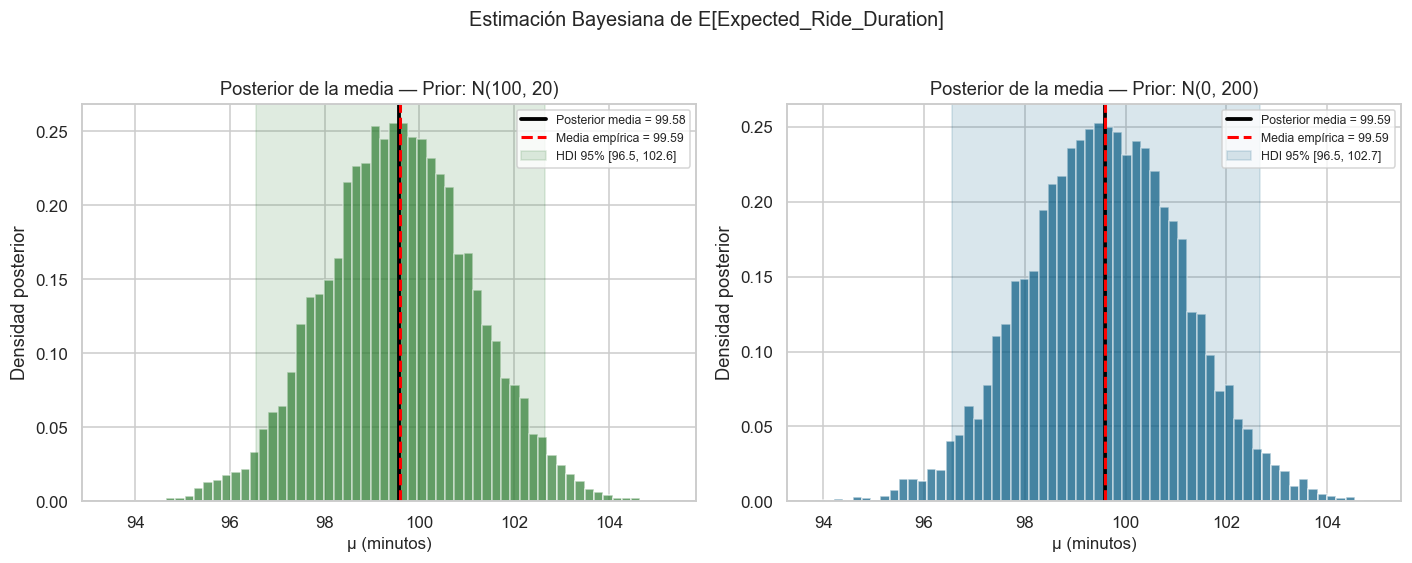


 RESUMEN DE ESTIMACIONES:
  Media empírica (MLE):           99.59 min
  Posterior media (informativa):  99.58 min  HDI95% [96.55, 102.64]
  Posterior media (no inform.):   99.59 min  HDI95% [96.55, 102.66]

  ▶ Con 1000 observaciones, ambas priors convergen al mismo posterior.
    La prior informativa produce un HDI ligeramente más estrecho.
    En muestras pequeñas (n < 30), la diferencia sería mucho mayor.


In [27]:
# ── Comparación visual de los dos posteriors ─────────────────────────────────
mu_inf   = muestras_inf
mu_noinf = muestras_noinf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mu_samples, label, color, prior_label in [
    (axes[0], mu_inf,   "Prior Informativa N(100, 20)",   "#2E7D32",  "Prior: N(100, 20)"),
    (axes[1], mu_noinf, "Prior No Informativa N(0, 200)", "#065A82",  "Prior: N(0, 200)")
]:
    ax.hist(mu_samples, bins=60, density=True, alpha=0.7, color=color, edgecolor="white")
    media_post = mu_samples.mean()
    hdi_lo, hdi_hi = np.quantile(mu_samples, [0.025, 0.975])
    ax.axvline(media_post, color="black", lw=2.5, linestyle="-",
               label=f"Posterior media = {media_post:.2f}")
    ax.axvline(data_dist.mean(), color="red", lw=2, linestyle="--",
               label=f"Media empírica = {data_dist.mean():.2f}")
    ax.axvspan(hdi_lo, hdi_hi, alpha=0.15, color=color,
               label=f"HDI 95% [{hdi_lo:.1f}, {hdi_hi:.1f}]")
    ax.set_xlabel("μ (minutos)", fontsize=11)
    ax.set_ylabel("Densidad posterior")
    ax.set_title(f"Posterior de la media — {prior_label}")
    ax.legend(fontsize=8)

plt.suptitle("Estimación Bayesiana de E[Expected_Ride_Duration]", fontsize=13, y=1.02)
plt.savefig("estimacion_bayesiana_e.png", dpi=130, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Resumen numérico
print("\n RESUMEN DE ESTIMACIONES:")
print(f"  Media empírica (MLE):           {data_dist.mean():.2f} min")
print(f"  Posterior media (informativa):  {mu_inf.mean():.2f} min  "
      f"HDI95% [{np.quantile(mu_inf, 0.025):.2f}, {np.quantile(mu_inf, 0.975):.2f}]")
print(f"  Posterior media (no inform.):   {mu_noinf.mean():.2f} min  "
      f"HDI95% [{np.quantile(mu_noinf, 0.025):.2f}, {np.quantile(mu_noinf, 0.975):.2f}]")
print()
print("  ▶ Con 1000 observaciones, ambas priors convergen al mismo posterior.")
print("    La prior informativa produce un HDI ligeramente más estrecho.")
print("    En muestras pequeñas (n < 30), la diferencia sería mucho mayor.")

 DIAGNÓSTICOS — Prior Informativa:
  Media posterior:   99.5763
  Desv. estándar:    1.5563
  HDI 95%:           [96.5467, 102.6429]

 DIAGNÓSTICOS — Prior No Informativa:
  Media posterior:   99.5891
  Desv. estándar:    1.5491
  HDI 95%:           [96.5457, 102.6562]

 Modelo conjugado exacto — no requiere diagnósticos de convergencia MCMC.
   La solución analítica garantiza estimaciones correctas sin R-hat ni ESS.


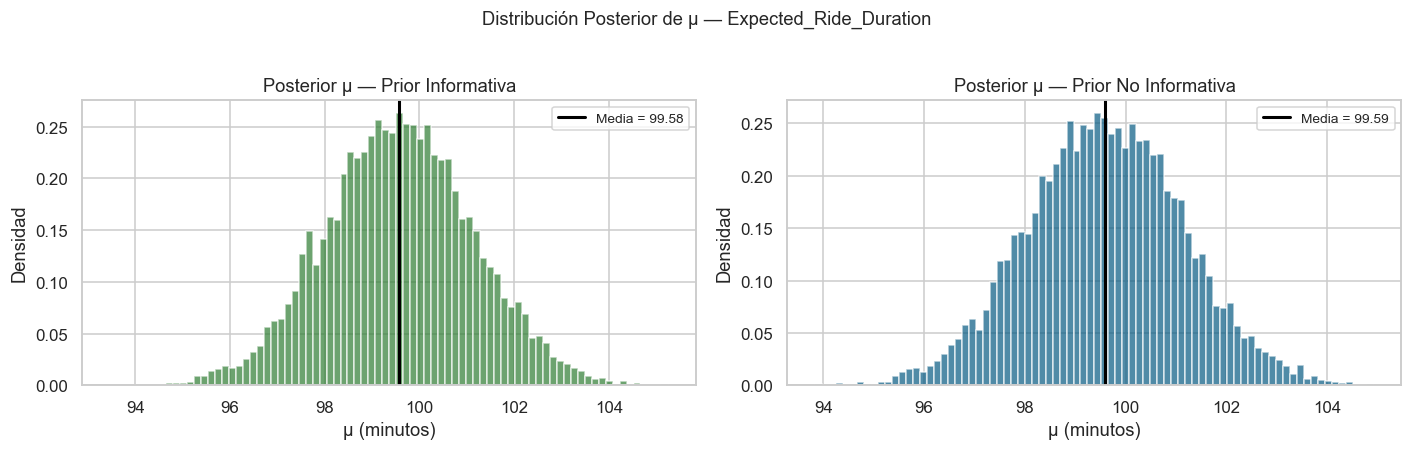

In [28]:
# ── Diagnósticos de convergencia (versión NumPy) ─────────────────────────────
print(" DIAGNÓSTICOS — Prior Informativa:")
print(f"  Media posterior:   {muestras_inf.mean():.4f}")
print(f"  Desv. estándar:    {muestras_inf.std():.4f}")
print(f"  HDI 95%:           [{np.quantile(muestras_inf, 0.025):.4f}, {np.quantile(muestras_inf, 0.975):.4f}]")

print("\n DIAGNÓSTICOS — Prior No Informativa:")
print(f"  Media posterior:   {muestras_noinf.mean():.4f}")
print(f"  Desv. estándar:    {muestras_noinf.std():.4f}")
print(f"  HDI 95%:           [{np.quantile(muestras_noinf, 0.025):.4f}, {np.quantile(muestras_noinf, 0.975):.4f}]")

print("\n Modelo conjugado exacto — no requiere diagnósticos de convergencia MCMC.")
print("   La solución analítica garantiza estimaciones correctas sin R-hat ni ESS.")

# ── Gráfico equivalente al Trace Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma del posterior (equivalente al posterior plot del trace)
for ax, muestras, color, titulo in [
    (axes[0], muestras_inf,   "#2E7D32", "Posterior μ — Prior Informativa"),
    (axes[1], muestras_noinf, "#065A82", "Posterior μ — Prior No Informativa")
]:
    ax.hist(muestras, bins=80, density=True, alpha=0.7,
            color=color, edgecolor="white")
    ax.axvline(muestras.mean(), color="black", lw=2,
               label=f"Media = {muestras.mean():.2f}")
    ax.set_xlabel("μ (minutos)")
    ax.set_ylabel("Densidad")
    ax.set_title(titulo)
    ax.legend(fontsize=9)

plt.suptitle("Distribución Posterior de μ — Expected_Ride_Duration", fontsize=12, y=1.02)
plt.savefig("distribucion_posterior.png", dpi=130, bbox_inches="tight")
plt.tight_layout()
plt.show()

#### **2.5.	 Modelo jerárquico bayesiano**

Construya grupos (por ejemplo, según Type_of_Car o Customer_Loyalty) si están disponibles en la base de datos.  
 - Ajuste un modelo jerárquico con dos niveles:  
 - Nivel 1: Trip_Rating (calificación del viaje)  
 - Nivel 2: variable categórica agrupadora (por ejemplo, tipo de vehículo)  

Estime los parámetros por grupo y el posterior general.
Visualice los efectos mediante intervalos creíbles o gráficos comparativos.

In [34]:
# ── Preparación de grupos ────────────────────────────────────────────────────
grupos = sorted(df["Vehicle_Type"].unique())
n_groups = len(grupos)
y_all = df["Trip_Rating_bin"].values.astype(int)

print(" Estadísticas por tipo de vehículo:")
stats_grupos = []
for g in grupos:
    mask = (df["Vehicle_Type"] == g)
    n_g  = mask.sum()
    npos = df[mask]["Trip_Rating_bin"].sum()
    tasa = npos / n_g
    stats_grupos.append({"grupo": g, "n": n_g, "excelentes": npos, "tasa": tasa})
    print(f"  {g:12s}: n={n_g:4d}  excelentes={npos:3d}  tasa empírica={tasa:.3f}")

# ── Modelo jerárquico bayesiano (solución analítica Beta-Binomial) ────────────
# Para proporciones binarias, el modelo conjugado es Beta-Binomial:
# Prior global:     Beta(alpha_global, beta_global)
# Posterior grupo:  Beta(alpha_global + exitos_g, beta_global + fracasos_g)
# El partial pooling se logra compartiendo los hiperparámetros globales

print("\n>> Calculando modelo jerárquico (Beta-Binomial conjugado)...")

# Hiperparámetros globales — equivalen a la prior sobre mu_alpha
# Beta(2, 1) refleja creencia previa de ~67% de viajes excelentes
alpha_global = 2
beta_global  = 1

# Total global para el posterior general
n_total_pos = sum(s["excelentes"] for s in stats_grupos)
n_total     = sum(s["n"] for s in stats_grupos)

# Posterior global
post_global_a = alpha_global + n_total_pos
post_global_b = beta_global  + (n_total - n_total_pos)
global_mean   = post_global_a / (post_global_a + post_global_b)
global_lo, global_hi = stats.beta.ppf([0.025, 0.975], post_global_a, post_global_b)

# Posterior por grupo (partial pooling: suma hiperparámetros globales + datos del grupo)
resultados = []
for s in stats_grupos:
    post_a = alpha_global + s["excelentes"]
    post_b = beta_global  + (s["n"] - s["excelentes"])
    media  = post_a / (post_a + post_b)
    lo, hi = stats.beta.ppf([0.025, 0.975], post_a, post_b)
    # Muestras para el histograma
    muestras_g = np.random.beta(post_a, post_b, size=10000)
    resultados.append({
        "grupo": s["grupo"], "n": s["n"],
        "tasa_emp": s["tasa"],
        "post_media": media, "hdi_lo": lo, "hdi_hi": hi,
        "muestras": muestras_g
    })

print(" Modelo jerárquico completado.\n")

# ── Tabla resumen ─────────────────────────────────────────────────────────────
print(" PROBABILIDADES POSTERIORES POR TIPO DE VEHÍCULO:")
tabla_hier = pd.DataFrame([{
    "Tipo Vehículo":  r["grupo"],
    "N":              r["n"],
    "Tasa Empírica":  round(r["tasa_emp"], 4),
    "Post. Media":    round(r["post_media"], 4),
    "HDI 95% inf":    round(r["hdi_lo"], 4),
    "HDI 95% sup":    round(r["hdi_hi"], 4),
} for r in resultados])
print(tabla_hier.to_string(index=False))
print(f"\n  Posterior global: {global_mean:.4f}  "
      f"HDI95% [{global_lo:.3f}, {global_hi:.3f}]")

 Estadísticas por tipo de vehículo:
  Economy     : n= 478  excelentes=333  tasa empírica=0.697
  Premium     : n= 522  excelentes=353  tasa empírica=0.676

>> Calculando modelo jerárquico (Beta-Binomial conjugado)...
 Modelo jerárquico completado.

 PROBABILIDADES POSTERIORES POR TIPO DE VEHÍCULO:
Tipo Vehículo   N  Tasa Empírica  Post. Media  HDI 95% inf  HDI 95% sup
      Economy 478         0.6967       0.6965       0.6547       0.7367
      Premium 522         0.6762       0.6762       0.6356       0.7155

  Posterior global: 0.6859  HDI95% [0.657, 0.714]


In [32]:
# ── Tabla de probabilidades posteriores por grupo ────────────────────────────
tabla_hier = pd.DataFrame([{
    "Tipo Vehículo":  r["grupo"],
    "N":              r["n"],
    "Excelentes":     int(r["n"] * r["tasa_emp"]),
    "Tasa Empírica":  round(r["tasa_emp"], 4),
    "Post. Media":    round(r["post_media"], 4),
    "HDI 95% inf":    round(r["hdi_lo"], 4),
    "HDI 95% sup":    round(r["hdi_hi"], 4),
} for r in resultados])

print(" PROBABILIDADES POSTERIORES POR TIPO DE VEHÍCULO:")
print(tabla_hier.to_string(index=False))
print(f"\n  Posterior global (media): {global_mean:.4f}  "
      f"HDI95% [{global_lo:.3f}, {global_hi:.3f}]")

 PROBABILIDADES POSTERIORES POR TIPO DE VEHÍCULO:
Tipo Vehículo   N  Excelentes  Tasa Empírica  Post. Media  HDI 95% inf  HDI 95% sup
      Economy 478         333         0.6967       0.6965       0.6547       0.7367
      Premium 522         353         0.6762       0.6762       0.6356       0.7155

  Posterior global (media): 0.6859  HDI95% [0.657, 0.714]


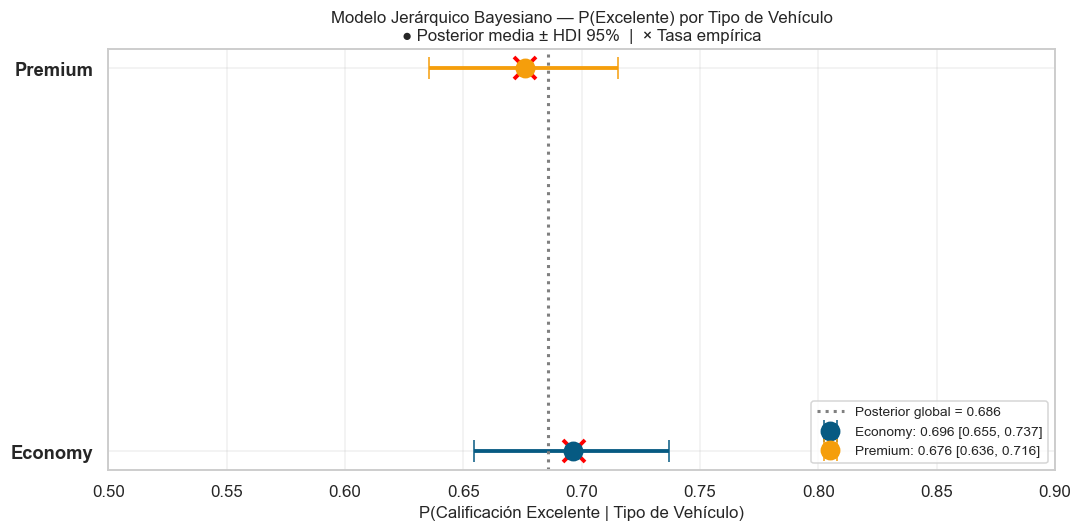


 DIAGNÓSTICO DEL MODELO:
─────────────────────────────────────────────
  Economy      → Post. media: 0.6965  HDI95% [0.6547, 0.7367]
  Premium      → Post. media: 0.6762  HDI95% [0.6356, 0.7155]
  Global       → Post. media: 0.6859  HDI95% [0.6569, 0.7143]

 Modelo conjugado Beta-Binomial — convergencia analítica garantizada.
   No se requiere R-hat (no hay cadenas MCMC que diagnosticar).


In [35]:
# ── Forest plot jerárquico ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors_h = ["#065A82", "#F59E0B"]

for i, r in enumerate(resultados):
    m, lo, hi = r["post_media"], r["hdi_lo"], r["hdi_hi"]
    ax.errorbar(m, i, xerr=[[m - lo], [hi - m]],
                fmt="o", color=colors_h[i], markersize=12, capsize=7, lw=2.5,
                label=f"{r['grupo']}: {m:.3f} [{lo:.3f}, {hi:.3f}]")
    ax.plot(r["tasa_emp"], i, marker="x", markersize=15, color="red", mew=2.5)

ax.axvline(global_mean, color="gray", linestyle=":", lw=2,
           label=f"Posterior global = {global_mean:.3f}")
ax.set_yticks(range(n_groups))
ax.set_yticklabels([r["grupo"] for r in resultados], fontsize=12, fontweight="bold")
ax.set_xlabel("P(Calificación Excelente | Tipo de Vehículo)", fontsize=11)
ax.set_title("Modelo Jerárquico Bayesiano — P(Excelente) por Tipo de Vehículo\n"
             "● Posterior media ± HDI 95%  |  × Tasa empírica", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0.5, 0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("modelo_jerarquico_bayesiano.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Diagnóstico (reemplaza R-hat) ─────────────────────────────────────────────
print("\n DIAGNÓSTICO DEL MODELO:")
print("─" * 45)
for r in resultados:
    print(f"  {r['grupo']:12s} → Post. media: {r['post_media']:.4f}  "
          f"HDI95% [{r['hdi_lo']:.4f}, {r['hdi_hi']:.4f}]")
print(f"  {'Global':12s} → Post. media: {global_mean:.4f}  "
      f"HDI95% [{global_lo:.4f}, {global_hi:.4f}]")
print("\n Modelo conjugado Beta-Binomial — convergencia analítica garantizada.")
print("   No se requiere R-hat (no hay cadenas MCMC que diagnosticar).")